# Smart Manufacturing

## The use of predictive analytics to minimize downtime in manufacturing by identifying root causes of failure.

Amelia Farrell
5/12/25



In [1]:
# Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

# Change to the google drive directory
%cd /content/drive/MyDrive/Colab\ Notebooks/DSC680

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/DSC680


In [2]:
# Libaraies needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading Data

In [4]:
# loading dataset as a data frame
df = pd.read_csv('predictive_maintenance.csv')
df = pd.DataFrame(df)

# view first 5 rows
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# 2. EDA & Data Transformations

Now that we have our data. We need to understand it's structure and transform it where needed for our anaylsis.

In [5]:
# Count the number of rows
len(df)

10000

In [6]:
# Count of each distinct value in the "Failure Type" column
failure_type_counts = df['Failure Type'].value_counts()

print(failure_type_counts)

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


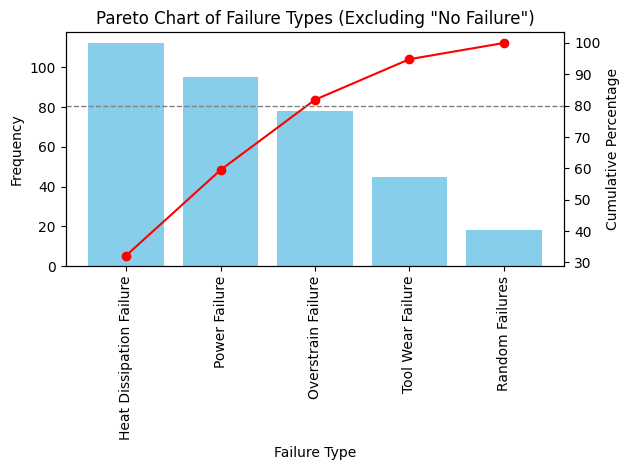

In [7]:
# Filter out "No Failure"
filtered_df_OnlyFailures = df[df['Failure Type'] != 'No Failure']

# Count each remaining failure type
failure_counts = filtered_df_OnlyFailures['Failure Type'].value_counts()

# Calculate cumulative percentage
cumulative_percentage = failure_counts.cumsum() / failure_counts.sum() * 100

# Plot Pareto chart
fig, ax1 = plt.subplots()

# Bar plot
ax1.bar(failure_counts.index, failure_counts.values, color='skyblue')
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Failure Type')
ax1.set_title('Pareto Chart of Failure Types (Excluding "No Failure")')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(failure_counts.index, cumulative_percentage.values, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Cumulative Percentage')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Since "Failure Type" and "Type" are in text, we want to encode each different type with a number via label encoding. This can be done with pandas.factorize() to convert the text features into numeric variables for our corrilation martix and model building.

In [8]:
# Encode 'Failure Type'
df['Failure Type Code'], failure_type_labels = pd.factorize(df['Failure Type'])

# Encode 'Type'
df['Type Code'], type_labels = pd.factorize(df['Type'])

# To view the mappings
print("Failure Type Mapping:")
print(dict(enumerate(failure_type_labels)))

print("\nType Mapping:")
print(dict(enumerate(type_labels)))

Failure Type Mapping:
{0: 'No Failure', 1: 'Power Failure', 2: 'Tool Wear Failure', 3: 'Overstrain Failure', 4: 'Random Failures', 5: 'Heat Dissipation Failure'}

Type Mapping:
{0: 'M', 1: 'L', 2: 'H'}


It is improtant to note the output (0: 'No Failure', etc.) so we can understand the output of our final model.

Next we want to look at how the existing variables corrilate.

<ipython-input-9-4830bf8c20f2>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_OnlyFailures.drop(columns='UDI', inplace=True)


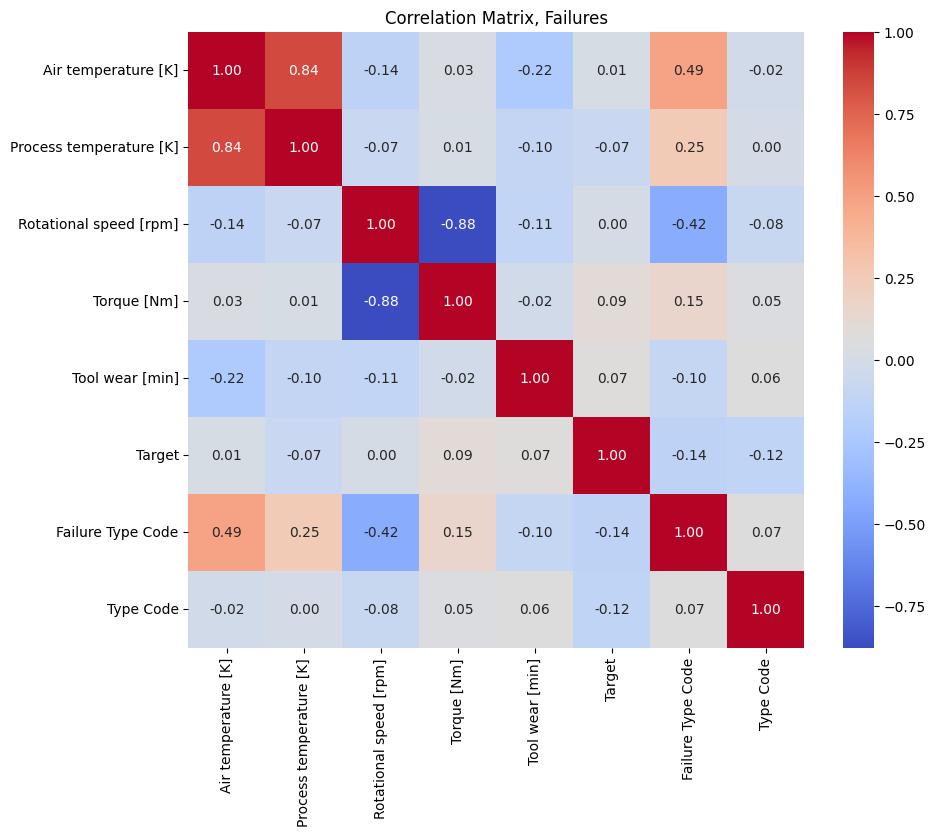

In [9]:
# Filter out "No Failure"
filtered_df_OnlyFailures = df[df['Failure Type'] != 'No Failure']
filtered_df_OnlyFailures.drop(columns='UDI', inplace=True)

# Compute correlation matrix
correlation_matrix_failures = filtered_df_OnlyFailures.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_failures, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix, Failures")
plt.show()

We can see that Rotational speed and Torque are highly negitivly corrilated (-0.88). Due to our industry knowlage, this makes perfect sence and likly exisits within machiane without failure. As Torque lowers with an increase in speed. We can confirm this by plotting the corrilation of the machines without failure.

<ipython-input-10-870796f4d435>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_NoFailure.drop(columns='UDI', inplace=True)


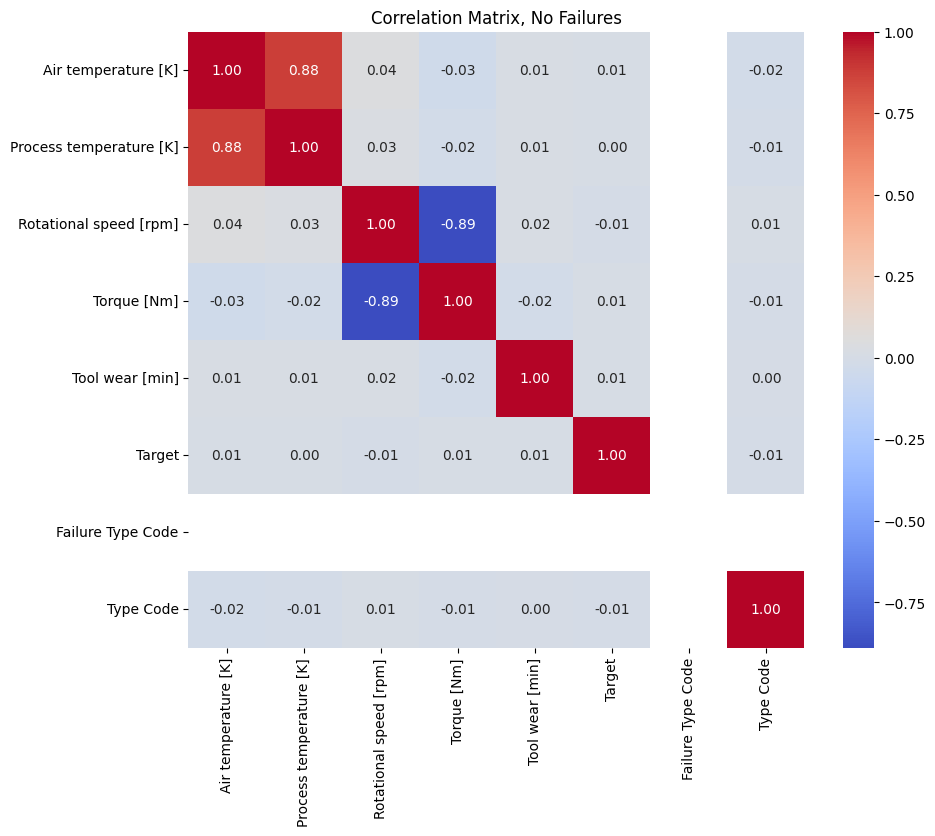

In [10]:
# Filter ON "No Failure"
filtered_df_NoFailure = df[df['Failure Type'] == 'No Failure']
filtered_df_NoFailure.drop(columns='UDI', inplace=True)

# Compute correlation matrix
correlation_matrix_NoFailure = filtered_df_NoFailure.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_NoFailure, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix, No Failures")
plt.show()

After viewing both correlations, we can already start to see patterns emerge. Rotational speed and Torque are slightly more correlated (-0.89) for the machines without failure and Air Temperature and Processes Temperature have a higher R value (0.88) versus those with failures (0.84). This could indicate that the more distance between Rotational speed and Torque lead to failures and the higher the difference in Air Temperature and Processes Temperature, the more likely a machine is to fail.

Next we want to engineer new features that may be important for predicting failure. We choose to create a two to features based on our findings within the correlations above and industry knowledge.

1. Temp Diff = Process Temperature - Air Temperature difference
2. Torque/Speed = Torque / Rotational Speed

In [11]:
# 1. Creating new logically meaningful difference and ratio features
df['Temp Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Torque/Speed'] = df['Torque [Nm]'] / df['Rotational speed [rpm]'].replace(0, pd.NA)

# 2. Check correlation to target variable
df.drop(columns='UDI', inplace=True) # ID not needed for analysis

correlation = df.corr(numeric_only=True)['Failure Type Code'].sort_values(ascending=False)
print(correlation)

Failure Type Code          1.000000
Target                     0.828941
Torque/Speed               0.206078
Torque [Nm]                0.190346
Air temperature [K]        0.118486
Tool wear [min]            0.082888
Process temperature [K]    0.055579
Type Code                  0.014988
Rotational speed [rpm]    -0.119680
Temp Diff                 -0.154369
Name: Failure Type Code, dtype: float64


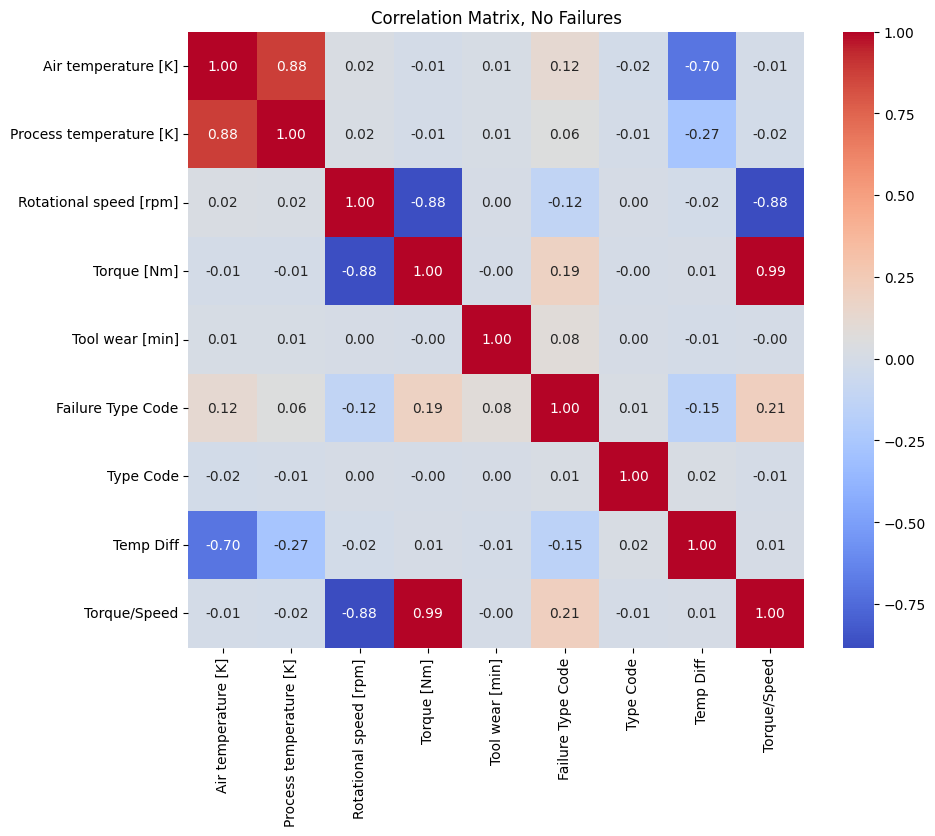

In [12]:
# Dropping "Target" as this is a duplicate of "Failure Type"
df.drop(columns='Target', inplace=True)

# Compute correlation matrix
correlation_matrix_newvars = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_newvars, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix, No Failures")
plt.show()

# 3. Cluster Analysis

Now that we have our new variables, lets see if we can find any other patterns by clustering similarities.

In [13]:
from sklearn.preprocessing import StandardScaler

# Select numeric features for clustering (excluding labels like Failure Type Code)
features_for_clustering = df[['Air temperature [K]', 'Process temperature [K]',
                              'Rotational speed [rpm]', 'Torque [Nm]',
                              'Tool wear [min]', 'Temp Diff', 'Torque/Speed']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)


In [14]:
from sklearn.cluster import KMeans

# Choose number of clusters (e.g., 3 to 6 is a good starting point)
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)


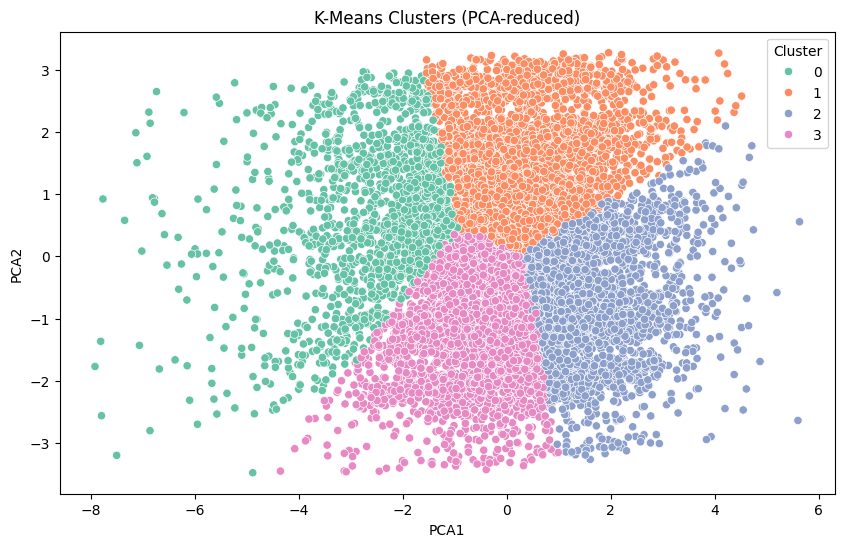

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('K-Means Clusters (PCA-reduced)')
plt.show()


In [16]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)


         Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
Cluster                                                                         
0                 301.126933               310.698624             1820.264089   
1                 301.939620               311.139651             1471.604437   
2                 298.771610               309.295361             1397.634417   
3                 298.322524               308.988559             1588.234537   

         Torque [Nm]  Tool wear [min]  Failure Type Code  Type Code  \
Cluster                                                               
0          25.915793       109.909567           0.041284   0.800131   
1          43.157338       109.914105           0.216482   0.787322   
2          50.052498       106.582078           0.108247   0.799366   
3          35.011727       105.902395           0.011441   0.816947   

         Temp Diff  Torque/Speed      PCA1      PCA2  
Cluster                        

In [17]:
pd.crosstab(df['Cluster'], df['Failure Type'])

Failure Type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Cluster,,,,,,
0,0,1482,0,31,3,10
1,110,2988,19,14,7,17
2,2,2399,59,50,6,6
3,0,2783,0,0,2,12


Key Takeaways from Clustering:
- Cluster 3 contains exclusively non-failure machines → a potential “baseline healthy” cluster.
- Cluster 1 has the highest failure concentration, especially for heat dissipation failures.
- Cluster 2 seems to be strongly associated with Power and Random Failures.
- Cluster 0 is a mixed cluster — mostly healthy, but with a few scattered failure cases.

While clustering uncovered some patterns, it does not necessarily help us reach our goal of predicting failures.

In [18]:
# Save DataFrame to CSV
df.to_csv('predictive_maintenance_expanded.csv', index=False)

# 4. Model & Variable *Selection*

Now we will move on to training / building a macine learning model with two goals in mind. #1 -> Predict machine failures before they occur. # 2 -> Classify the type or root cause of failure (e.g., Heat Dissipation, Tool Wear).

In [8]:
# Load expanded DataFrame
df = pd.read_csv('predictive_maintenance_expanded.csv')

# 4A. Failure Prediction Model (Binary Classification)

We will be using XGBoost for our failure prediction model due to it's speed, how it handles non-linearities, and that it provides feature importance for interpretability. Our main goal being to train a binary classification model to predict whether a machine will fail (1) or not fail (0) based on our expaned data set.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

Prepare Data for specific model

In [9]:
# Binary label: 1 if failure, 0 if no failure
df['FailureBinary'] = df['Failure Type'].apply(lambda x: 0 if x == 'No Failure' else 1)

# Define feature columns (drop IDs and labels)
features = df.drop(columns=['Product ID', 'Failure Type', 'Failure Type Code', 'FailureBinary', 'Type'])
features = pd.get_dummies(features)  # encode Type if still present as string

# Define target
target = df['FailureBinary']

# Standardize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, target, test_size=0.3, random_state=42, stratify=target)

Train XGBoost Classifier

In [10]:
from xgboost import XGBClassifier

# Initialize and train model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:57:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Evaluate

In [11]:
# Predict
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[2880   16]
 [  36   68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2896
           1       0.81      0.65      0.72       104

    accuracy                           0.98      3000
   macro avg       0.90      0.82      0.86      3000
weighted avg       0.98      0.98      0.98      3000


ROC AUC Score: 0.9706823735656609


Our model did not do well at predicting machines that fail (1 Recall = 0.65), likly due the high number of 'No Failure's vs 'Failures'. Lets undersample 'No Failure's to help reduce the bais within our model.

Undersampling the Majority Class (0, No Failures)

In [12]:
# Separate the classes
df_failures = df[df['Failure Type'] != 'No Failure']
df_no_failure = df[df['Failure Type'] == 'No Failure']

# Undersample the 'No Failure' class to match the number of failure rows
df_no_failure_sampled = df_no_failure.sample(n=len(df_failures), random_state=42)

# Combine them into a new balanced DataFrame
df_balanced = pd.concat([df_failures, df_no_failure_sampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Binary target
df_balanced['FailureBinary'] = df_balanced['Failure Type'].apply(lambda x: 0 if x == 'No Failure' else 1)

Prepare Features and Labels

In [13]:
from sklearn.preprocessing import StandardScaler

# Drop unused columns
X = df_balanced.drop(columns=['Product ID', 'Failure Type', 'Failure Type Code', 'FailureBinary'])

# One-hot encode 'Type' if still present
X = pd.get_dummies(X)

# Labels
y = df_balanced['FailureBinary']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split & XGBoost Model

In [14]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:57:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Evaluate round two

In [15]:
# Predict
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[97  8]
 [10 94]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       105
           1       0.92      0.90      0.91       104

    accuracy                           0.91       209
   macro avg       0.91      0.91      0.91       209
weighted avg       0.91      0.91      0.91       209


ROC AUC Score: 0.9419413919413919


Looking at the balanced model, we see significant improvement in Recall for Failures (0.65 to 0.90) but a decline in overall accuracy (0.98 to 0.91). Even though the accuracy is lower, our focus is predicting failures, so this model will be chosen over the first.

Next, we want to see which variables had the largest impact on predicting weather or not a machine had a failure and what failure. We will do this using SHAP (SHapley Additive exPlanations) a library built to give local & global feature influence.

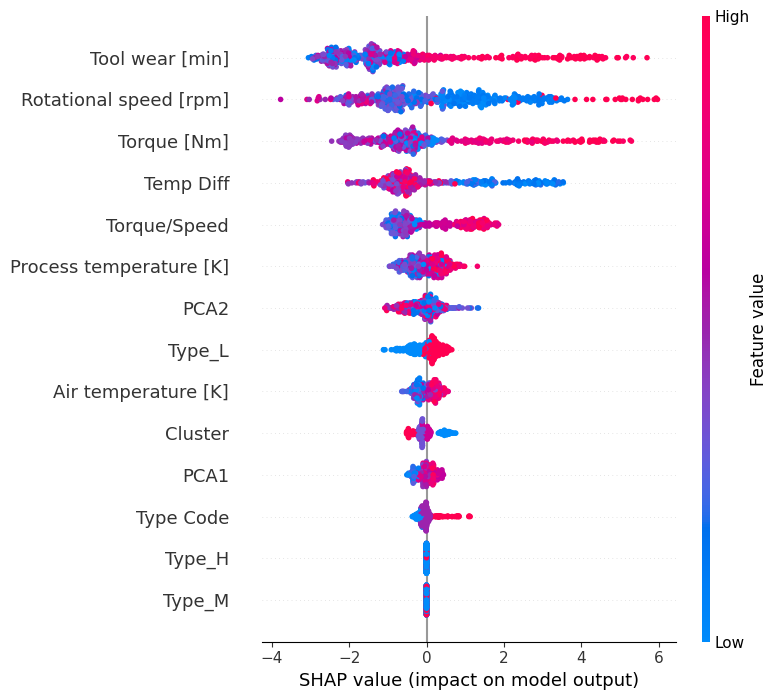

In [16]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_train)

# Summary plot of feature impact
shap.summary_plot(shap_values, X_train, feature_names=X.columns)

We interpret this pot with the Y-axis showing features ranked by importance (top = most influential). X-axis being the "SHAP value" (impact on prediction)
A positive "SHAP value" means that the feature pushes prediction toward failure.
A negative SHAP pushes prediction toward no failure. The color represents the observations value (Red = high, Blue = low).

With this understanding we can extract that Tool wear, specifically, high (min) tool wear strongly increases failure probability. Higher than average Rotational speed also contributes positively to failure as well as lower than average. Higher torque tends to increase risk as well, more than lower end torque (strong red presence on the right). A lower difference in temperatures is also slightly protective, bringing down the risk of failure if the difference is on the lower end. Lastly, Torque/Speed showed that a higher torque-to-speed ratio increases failure risk (likely mechanical stress).

# 4B. Root Cause Classification (Multiclass Classification)

While our XGBoost Model for Binary Classification helped us idenify some of the root causes buy looking into the most influentual variabels. Lets see if we can take it a step further and predicts the most likely failure type (e.g., Power Failure, Overstrain).

We will be using XGBoost here as well but tailerd for Multiclass Classification on Failures only.

In [17]:
# Keep only failure rows
df_failures = df[df['Failure Type'] != 'No Failure'].copy()

# Encode the multiclass target
df_failures['FailureClass'], failure_labels = pd.factorize(df_failures['Failure Type'])
print(dict(enumerate(failure_labels)))

{0: 'Power Failure', 1: 'Tool Wear Failure', 2: 'Overstrain Failure', 3: 'Random Failures', 4: 'Heat Dissipation Failure'}


Prepare Features and Labels

In [18]:
# Drop unused or label columns
X = df_failures.drop(columns=['Product ID', 'Failure Type', 'Failure Type Code', 'FailureBinary', 'FailureClass'])

# One-hot encode 'Type' if needed
X = pd.get_dummies(X)

# Target
y = df_failures['FailureClass']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

Train the XGBoost Multiclass Model

In [19]:
from xgboost import XGBClassifier

xgb_multi = XGBClassifier(objective='multi:softprob', num_class=len(failure_labels),
                          use_label_encoder=False, eval_metric='mlogloss', random_state=42)

xgb_multi.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:57:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=5, num_parallel_tree=None, ...)

Evaluate

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = xgb_multi.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=failure_labels))

Confusion Matrix:
 [[26  0  1  1  1]
 [ 1 11  2  0  0]
 [ 1  0 22  0  0]
 [ 1  1  0  3  0]
 [ 0  0  0  0 34]]

Classification Report:
                           precision    recall  f1-score   support

           Power Failure       0.90      0.90      0.90        29
       Tool Wear Failure       0.92      0.79      0.85        14
      Overstrain Failure       0.88      0.96      0.92        23
         Random Failures       0.75      0.60      0.67         5
Heat Dissipation Failure       0.97      1.00      0.99        34

                accuracy                           0.91       105
               macro avg       0.88      0.85      0.86       105
            weighted avg       0.91      0.91      0.91       105



From our inital EDA, we know that the distrubution of failur type is not even accross types.

- Heat Dissipation Failure ->    112
- Power Failure       ->          95
- Overstrain Failure ->           78
- Tool Wear Failure ->            45
- Random Failures  ->             18

Lets oversample the lesser types to see if we can decrease the model bias we see in Heat Dissipation Failure recall (1).

We will oversample using SMOTE (Synthetic Minority Over-sampling Technique) as it is  more effective than random oversampling since it generates synthetic examples rather than duplicating existing ones.

In [21]:
!pip install imbalanced-learn

Preparing Data and applying SMOTE Oversampling

In [22]:
from imblearn.over_sampling import SMOTE

# Features & labels
X = df_failures.drop(columns=['Product ID', 'Failure Type', 'Failure Type Code', 'FailureBinary', 'FailureClass'])
X = pd.get_dummies(X)

y = df_failures['FailureClass']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

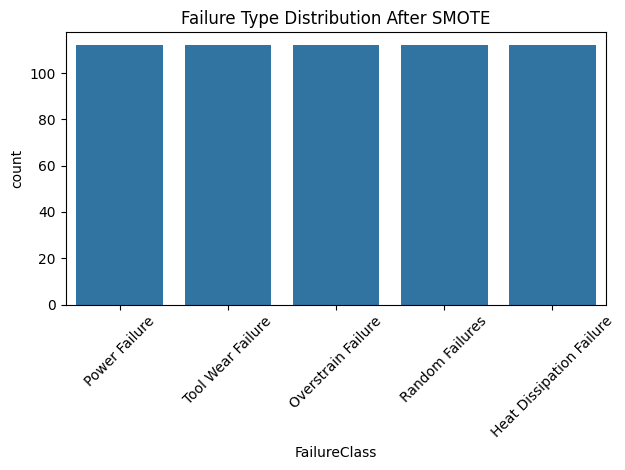

In [23]:
# check new class distribution
sns.countplot(x=y_resampled.map(dict(enumerate(failure_labels))))
plt.title("Failure Type Distribution After SMOTE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Train-Test Split & Scaling

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3, random_state=42, stratify=y_resampled)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Oversampled data on XGBoost Multiclass Model

In [25]:
xgb_smote = XGBClassifier(objective='multi:softprob',
                          num_class=len(failure_labels),
                          use_label_encoder=False,
                          eval_metric='mlogloss',
                          random_state=42)

xgb_smote.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:58:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=5, num_parallel_tree=None, ...)

Evaluate Oversampled data on XGBoost Multiclass Model

In [26]:
y_pred_smote = xgb_smote.predict(X_test_scaled)

print("Classification Report After SMOTE:\n")
print(classification_report(y_test, y_pred_smote, target_names=failure_labels))

Classification Report After SMOTE:

                          precision    recall  f1-score   support

           Power Failure       0.97      0.94      0.96        34
       Tool Wear Failure       1.00      0.97      0.98        33
      Overstrain Failure       0.94      1.00      0.97        34
         Random Failures       0.97      1.00      0.99        34
Heat Dissipation Failure       1.00      0.97      0.98        33

                accuracy                           0.98       168
               macro avg       0.98      0.98      0.98       168
            weighted avg       0.98      0.98      0.98       168



This time we saw an increase in overall accuracy (0.91 to 0.98) likely due to the addition of observations / data points added when oversampling (see count under "support" in Classification Report). We also see an increase in recall for Random Failures (0.60 to 1) and similar recall and precision across the board. Meaning that the oversampled model preformed much better, removing the bias made by the large sample sizes of certain failures.

Now lets take a simliar look at feature importance using SHAP but broken up by failure type.

Feature impact for class: Power Failure


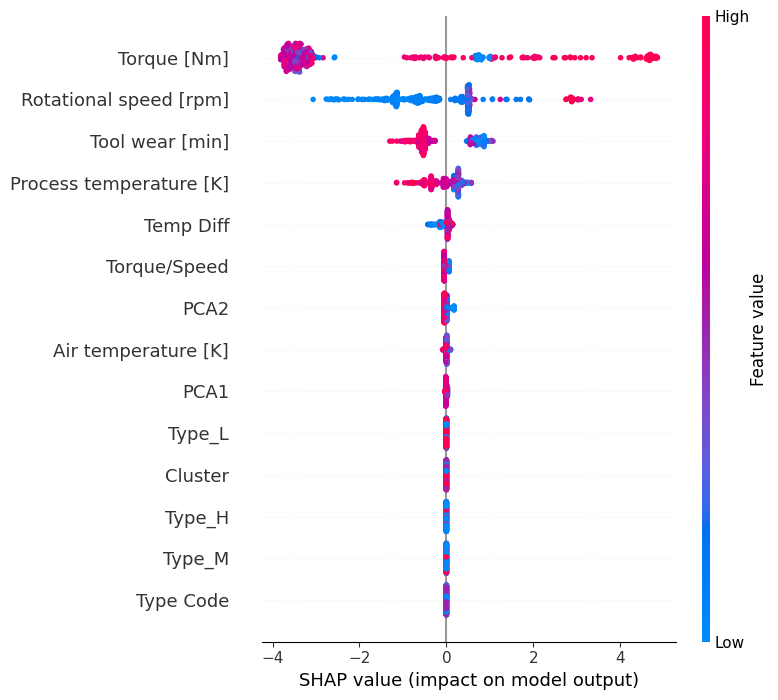

Feature impact for class: Tool Wear Failure


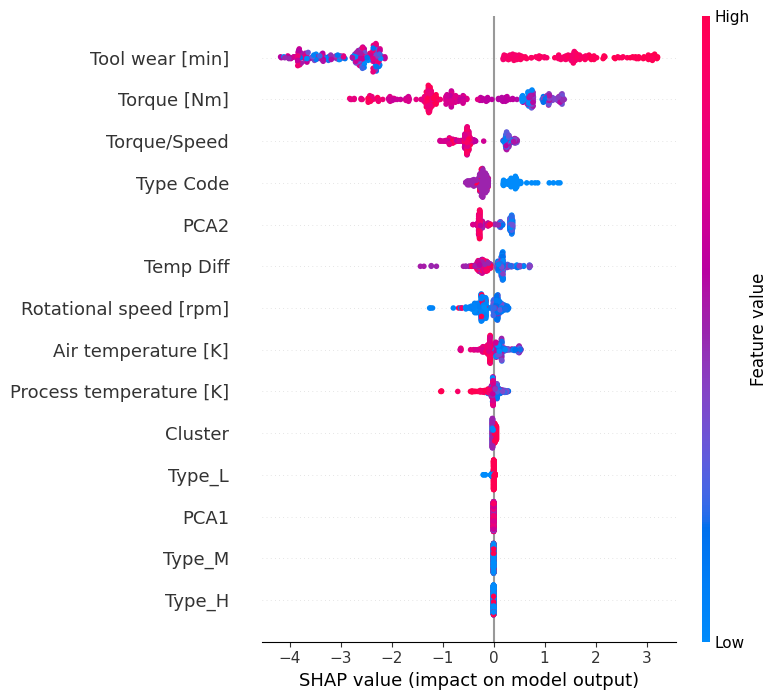

Feature impact for class: Overstrain Failure


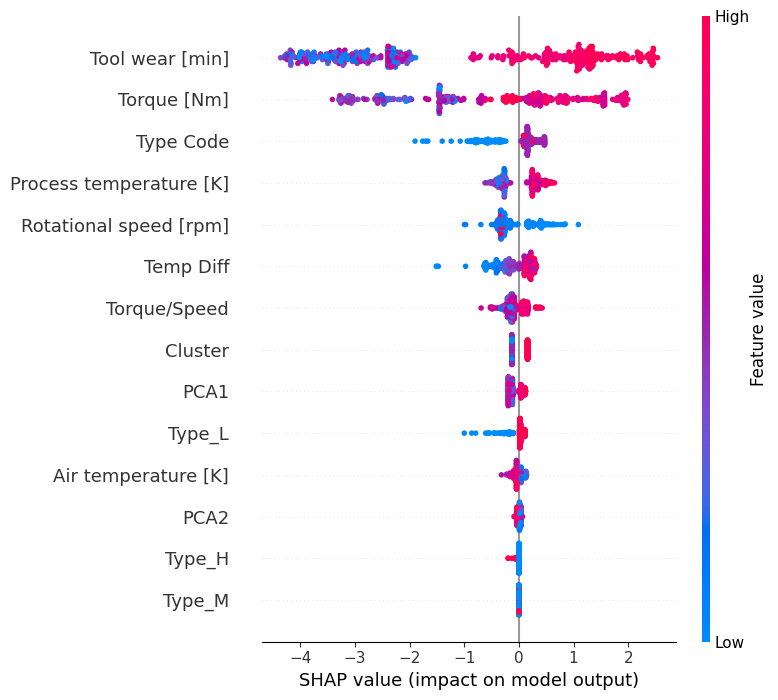

Feature impact for class: Random Failures


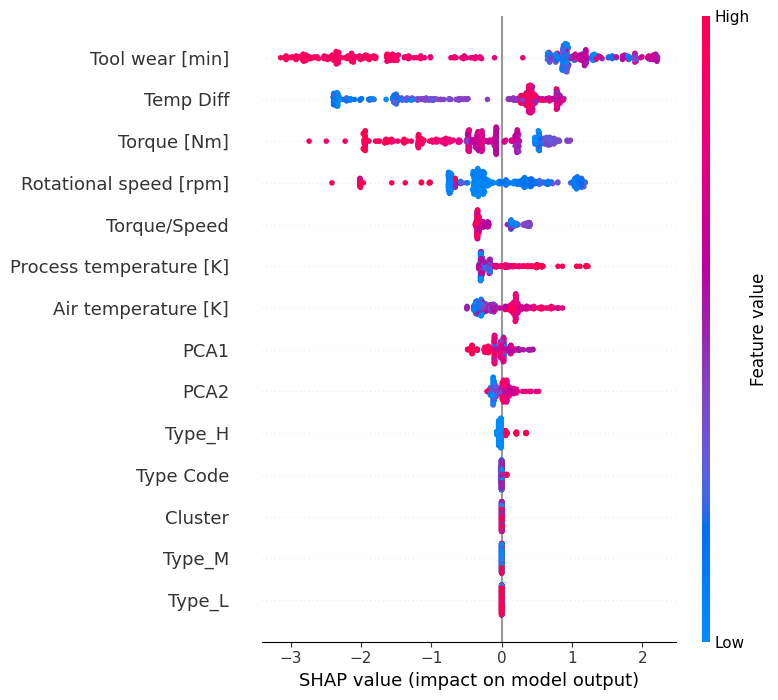

Feature impact for class: Heat Dissipation Failure


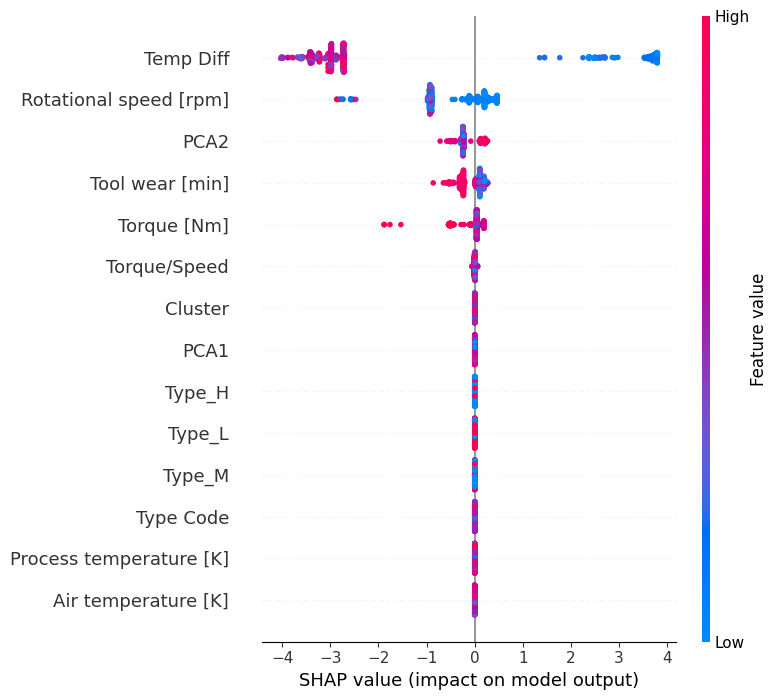

In [51]:
# Create explainer and SHAP values for multiclass model
explainer = shap.Explainer(xgb_smote)
shap_values = explainer(X_train_scaled)

# Summary plot for each class (failure type)
for i, label in enumerate(failure_labels):
    print(f"Feature impact for class: {label}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=X.columns)

# 5. Making a Prediction

Now that we have chosen and trained our ideal model, we want to test it on a random data point. We are using an observation from the data set since these were built to replicate real word machine output, rather than random measures.

In [28]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_resampled, y_resampled, test_size=0.3, stratify=y_resampled, random_state=42
)

In [50]:
import numpy as np

# Pick a random index from test set
rand_idx = np.random.randint(0, X_test_df.shape[0])

# Get the row and true label
random_sample = X_test_df.iloc[rand_idx]
true_class = failure_labels[y_test.iloc[rand_idx]]

# Predict
predicted_class_idx = xgb_smote.predict(random_sample.values.reshape(1, -1))[0]
predicted_class = failure_labels[predicted_class_idx]

print(f"True Failure Type:     {true_class}")
print(f"Predicted Failure Type: {predicted_class}")

True Failure Type:     Power Failure
Predicted Failure Type: Power Failure
